# Analysis of goblet cells in the CRC datasets

In [1]:
import pandas as pd
import numpy as np
import spatialdata_io
import spatialdata_plot 
import spatialdata as sd
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os
import warnings
import time
import matplotlib as mpl

from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from matplotlib.colors import ListedColormap, TwoSlopeNorm

warnings.filterwarnings("ignore")

#os.environ["CUDA_VISIBLE_DEVICES"] = "5"

/home/yzengbj/anaconda3/envs/factor/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/yzengbj/anaconda3/envs/factor/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Helvetica', 
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,    
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [3]:
RAW_PATH = "/home/yzengbj/data/colorectal_cancer" # Raw data
DATA_PATH = "/home/yzengbj/my_project/data/CRC" # Raw data
SAVE_PATH = "/home/yzengbj/my_project/results/CRC" # Deconvolution results
FIG_PATH = "/import/home2/yzengbj/factor/experiments/CRC/figures"

os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)
os.makedirs(os.path.join(FIG_PATH), exist_ok = True)

In [4]:
sdata_crop1 = sd.read_zarr('/import/home2/yzengbj/factor/results/CRC/sdata_hd_crop1.zarr')

version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


In [5]:
loading_008 = sdata_crop1['square_008um'].varm['loading']
loading_016 = sdata_crop1['square_016um'].varm['loading']

In [7]:
loading_016.to_csv('loading_016.csv')

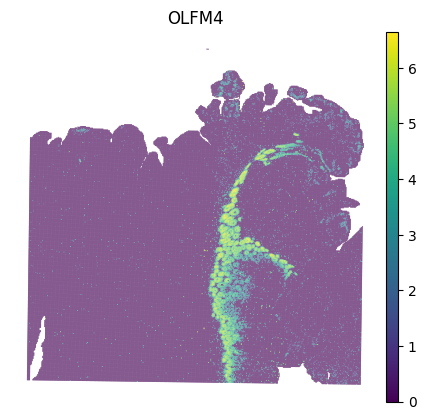

In [12]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'OLFM4',
              spot_size=60, img_key=None, frameon=False, title='OLFM4',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

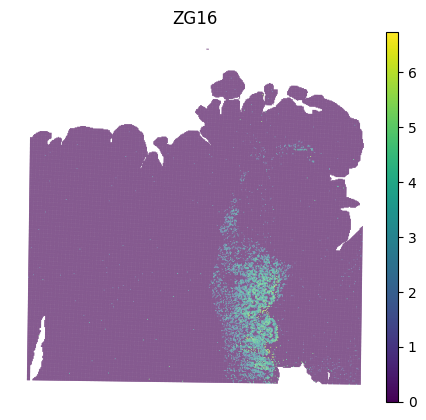

In [13]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'ZG16',
              spot_size=60, img_key=None, frameon=False, title='ZG16',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

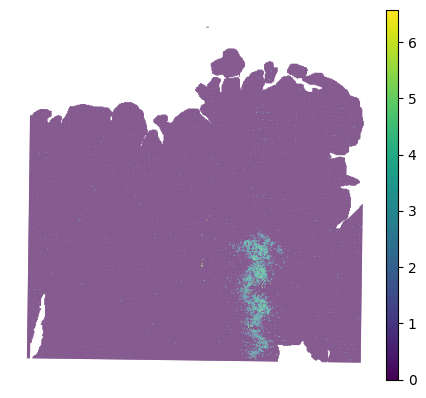

In [44]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'CA1',
              spot_size=60, img_key=None, frameon=False, title='',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

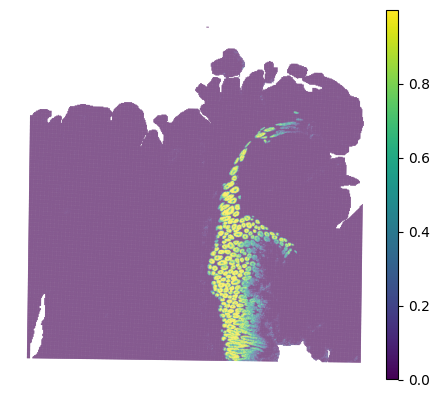

In [11]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'Goblet',
              spot_size=60, img_key=None, frameon=False, title='',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

In [180]:
RAW_PATH = "/import/home2/share/yqzeng/data/CRC"
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/CRC"
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/CRC" 

sample_size = 50000
save_path = os.path.join(SAVE_PATH, f"{sample_size}_spots", 'spicemix')
file_path = os.path.join(save_path, 'files')
os.makedirs(save_path, exist_ok=True)
os.makedirs(file_path, exist_ok=True)

In [181]:
factors = pd.read_csv(os.path.join(save_path, 'factors.csv'), index_col=0)
loadings = pd.read_csv(os.path.join(save_path, 'loadings.csv'), index_col=0)
coordinates = pd.read_csv(os.path.join(save_path, 'coordinates.csv'), index_col=0)

In [182]:
sdata_crop1_subsample = sdata_crop1['square_016um'][coordinates.index]

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


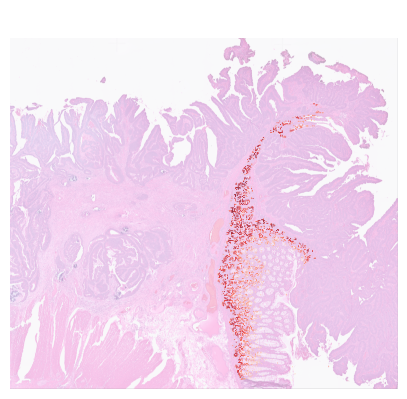

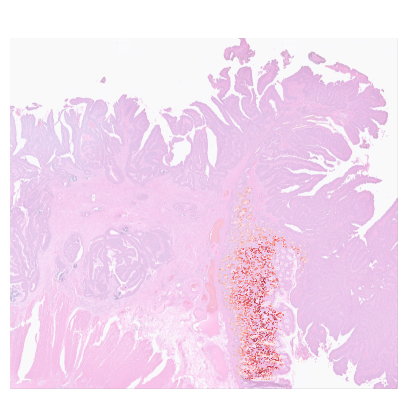

In [183]:
proportion_threshold = 0.1
# norm = TwoSlopeNorm(vcenter=0)
# ct_plot = ["Tumor III", "CAF", "Goblet", "Macrophage"]
# reverse_list = [False, True, True, False]
factor_list = ["Factor_3", "Factor_18"]
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)
ct = 'Goblet'

for factor in factor_list:
        axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
        # axes off
        axes.set_axis_off()

        sdata_crop1_subsample.obs['tmp'] = factors[factor]
        # if reverse_list[ct_plot.index(ct)]:
        #     sdata_crop1_subsample.obs['tmp'] = -sdata_crop1_subsample.obs['tmp']
        filter = sdata_crop1_subsample.obsm['proportion'][ct]>=proportion_threshold
        if filter.sum() == 0:
                print(f"No spots meet the proportion threshold for cell type {ct}.")
        sdata_crop1_subsample.obs['tmp'] = sdata_crop1_subsample.obs['tmp'].where(filter, 0)
        sdata_crop1['square_016um'].obs['tmp'] = 0
        sdata_crop1['square_016um'].obs['tmp'][coordinates.index] = sdata_crop1_subsample.obs['tmp']
        #
        plot = sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
                "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
                color="tmp",# method='datashader',
                table_name='square_016um',
                datashader_reduction='mean',
                cmap=program_cmap,
                #norm=norm,
                method='matplotlib',
        ).pl.show(title='', 
                coordinate_systems="global", ax=axes, dpi=100, frameon=None,
                #save='CRC_016_{}.pdf'.format(ct), 
                colorbar=False)

In [184]:
save_path = os.path.join(SAVE_PATH, f"{sample_size}_spots", 'mofa')

factors = pd.read_csv(os.path.join(save_path, 'factors.csv'), index_col=0)
loadings = pd.read_csv(os.path.join(save_path, 'loadings.csv'), index_col=0)

sdata_crop1_subsample = sdata_crop1['square_016um'][factors.index]

INFO     Rasterizing image for faster rendering.                                                                   


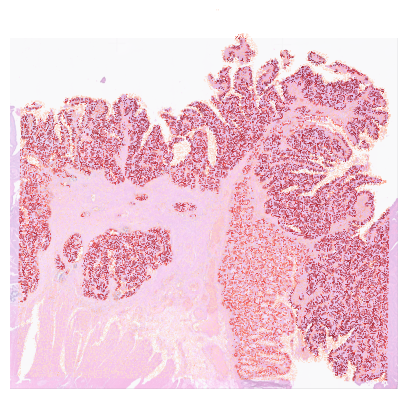

In [185]:
proportion_threshold = 0.1
# norm = TwoSlopeNorm(vcenter=0)
# ct_plot = ["Tumor III", "CAF", "Goblet", "Macrophage"]
# reverse_list = [False, True, True, False]
factor_list = ["Factor1"]
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)
ct = 'Goblet'

for factor in factor_list:
        axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
        # axes off
        axes.set_axis_off()

        sdata_crop1_subsample.obs['tmp'] = factors[factor]
        # normalize the factor values to [0, 1]
        sdata_crop1_subsample.obs['tmp'] = (sdata_crop1_subsample.obs['tmp'] - sdata_crop1_subsample.obs['tmp'].min()) / (sdata_crop1_subsample.obs['tmp'].max() - sdata_crop1_subsample.obs['tmp'].min())
        # if reverse_list[ct_plot.index(ct)]:
        #     sdata_crop1_subsample.obs['tmp'] = -sdata_crop1_subsample.obs['tmp']
        # filter = sdata_crop1_subsample.obsm['proportion'][ct]>=proportion_threshold
        # if filter.sum() == 0:
        #         print(f"No spots meet the proportion threshold for cell type {ct}.")
        # sdata_crop1_subsample.obs['tmp'] = sdata_crop1_subsample.obs['tmp'].where(filter, 0)
        sdata_crop1['square_016um'].obs['tmp'] = 0
        sdata_crop1['square_016um'].obs['tmp'][factors.index] = sdata_crop1_subsample.obs['tmp']
        #
        plot = sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
                "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
                color="tmp",# method='datashader',
                table_name='square_016um',
                datashader_reduction='mean',
                cmap=program_cmap,
                #norm=norm,
                method='matplotlib',
        ).pl.show(title='', 
                coordinate_systems="global", ax=axes, dpi=100, frameon=None,
                #save='CRC_016_{}.pdf'.format(ct), 
                colorbar=False)

In [17]:
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)

INFO     Rasterizing image for faster rendering.                                                                   


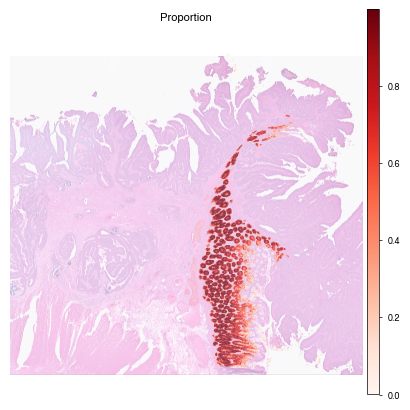

In [18]:
ct = 'Goblet'
axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
# axes off
axes.set_axis_off()
sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
        "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
        color=ct,# method='datashader',
        table_name='square_016um',
        datashader_reduction='mean',
        cmap=program_cmap,
        method='matplotlib',
).pl.show(title='Proportion', 
          coordinate_systems="global", ax=axes, dpi=100, frameon=None,
          #save=f'proportion_{ct}',
          colorbar=True,
          )


In [ ]:
mpl.rcParams.update({
    'font.family': 'Helvetica',  
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 300,
})

In [23]:
loading_xenium_ct = adata_xenium.varm['loading']['Goblet']

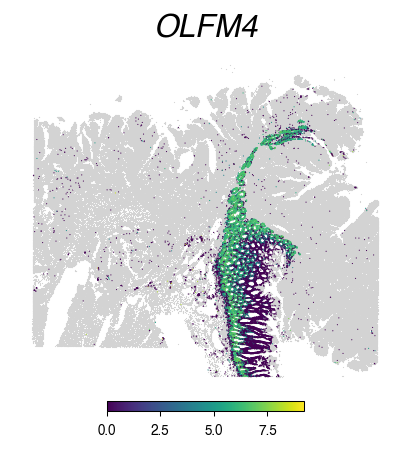

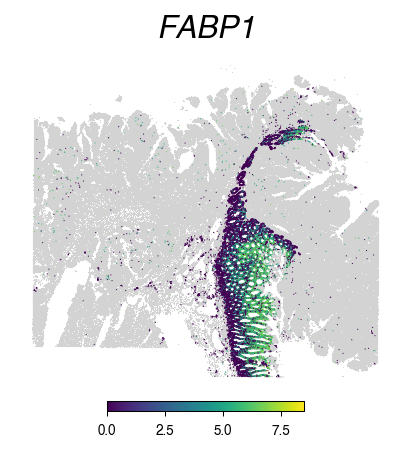

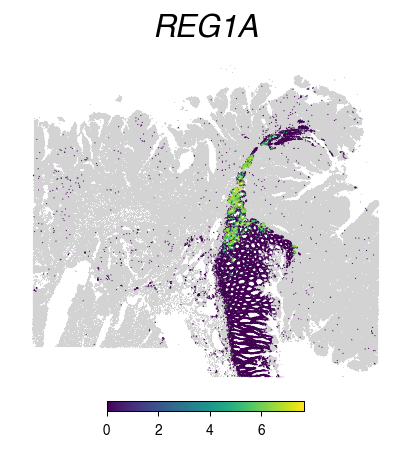

In [26]:
import scanpy as sc
adata_xenium = sc.read_h5ad(os.path.join("/home/yzengbj/my_project/results/CRC", "adata_xenium_filtered_10_18.h5ad"))
gene_list = ['OLFM4', 'FABP1', 'REG1A']

mask = adata_xenium.obsm['proportion']['Goblet'] > 0.1
for gene in gene_list:
    data = adata_xenium[:, gene].X.toarray()
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    background = ax.scatter(
        -adata_xenium.obsm['spatial'][:, 0],
        -adata_xenium.obsm['spatial'][:, 1],
        c='lightgray',
        s=0.3,
        linewidths=0
    )
    sc1 = ax.scatter(
        -adata_xenium.obsm['spatial'][mask, 0],
        -adata_xenium.obsm['spatial'][mask, 1],
        c=data[mask],
        s=0.3,
        cmap='viridis',
        linewidths=0
    )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')

    #cb.set_label('Expression', fontsize=12)

    #cb.set_ticks([])
    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(gene, fontsize=15, fontstyle='italic')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [8]:
sdata_crop1['square_016um']

AnnData object with n_obs × n_vars = 137051 × 2780
    obs: 'in_tissue', 'array_row', 'array_col', 'library_size', 'alpha', 'CAF', 'CD8_T_cell', 'Endothelial', 'Enteric_Glial', 'Enterocyte', 'Fibroblast', 'Goblet', 'Lymphatic_Endothelial', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating_Fibroblast', 'Proliferating_Immune_II', 'Proliferating_Macrophages', 'Tuft', 'Tumor_III', 'Tumor_V', 'cDC_I', 'mRegDC', 'vSM', 'program_CAF', 'program_CD8_T_cell', 'program_Endothelial', 'program_Enteric_Glial', 'program_Enterocyte', 'program_Fibroblast', 'program_Goblet', 'program_Lymphatic_Endothelial', 'program_Macrophage', 'program_Myofibroblast', 'program_Neutrophil', 'program_Pericytes', 'program_Plasma', 'program_Proliferating_Fibroblast', 'program_Proliferating_Immune_II', 'program_Proliferating_Macrophages', 'program_Tuft', 'program_Tumor_III', 'program_Tumor_V', 'program_cDC_I', 'program_mRegDC', 'program_vSM', 'location_id', 'region'
    var: 'gene_ids', 'fe

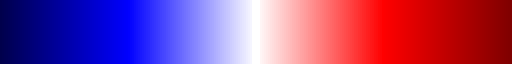

In [114]:
program_cmap=plt.get_cmap('seismic')
colors=program_cmap(np.arange(program_cmap.N))
colors[program_cmap.N//2-2:program_cmap.N//2+2,3] = 0
program_cmap = ListedColormap(colors)
norm = TwoSlopeNorm(vcenter=0)
program_cmap

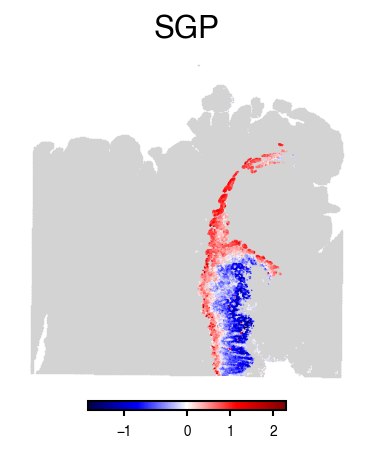

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = -sdata_crop1['square_016um'].obsm['factor'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap=program_cmap,
    linewidths=0,
    norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('SGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

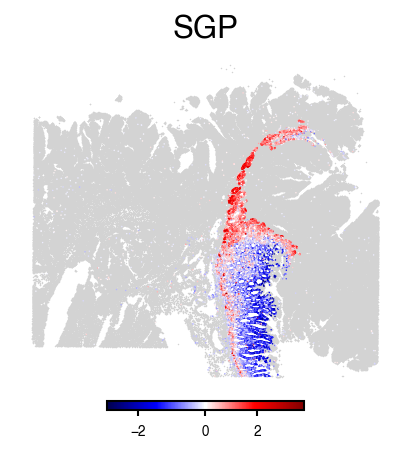

In [126]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = adata_xenium.obsm['factor'][ct]
prop = adata_xenium.obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    -adata_xenium.obsm['spatial'][mask, 0],
    -adata_xenium.obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    -adata_xenium.obsm['spatial'][~mask, 0],
    -adata_xenium.obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap=program_cmap,
    linewidths=0,
    norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('SGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

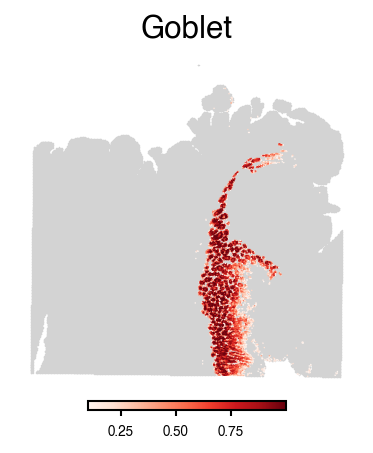

In [120]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = sdata_crop1['square_016um'].obsm['proportion'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Goblet', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

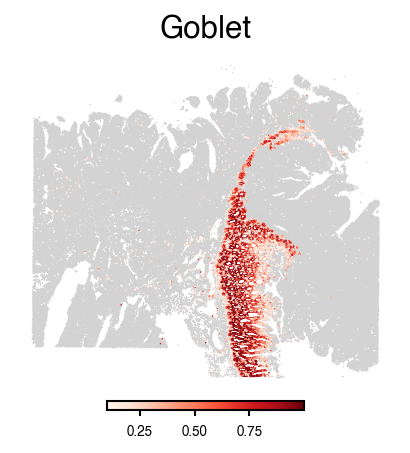

In [129]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = adata_xenium.obsm['proportion'][ct]
prop = adata_xenium.obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    -adata_xenium.obsm['spatial'][mask, 0],
    -adata_xenium.obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    -adata_xenium.obsm['spatial'][~mask, 0],
    -adata_xenium.obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Goblet', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

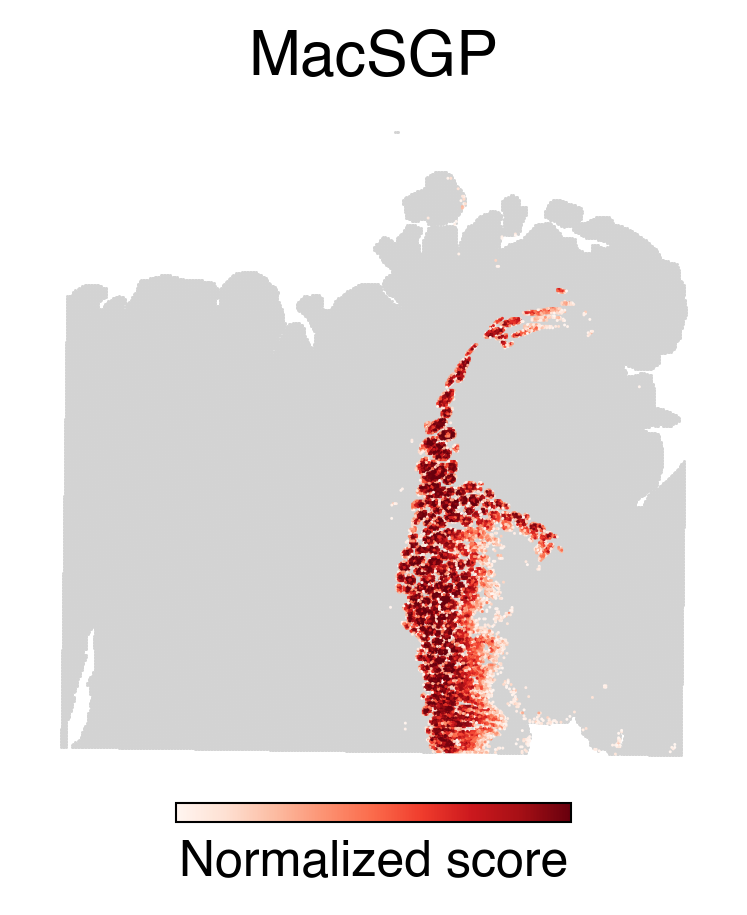

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = sdata_crop1['square_016um'].obsm['proportion'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
#norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('MacSGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

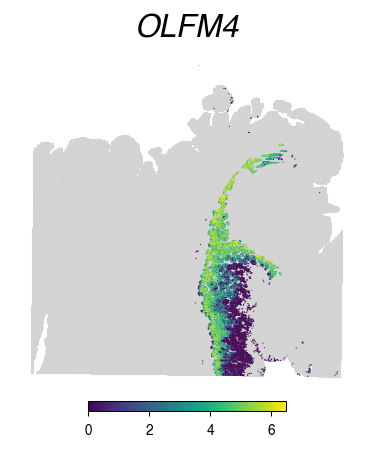

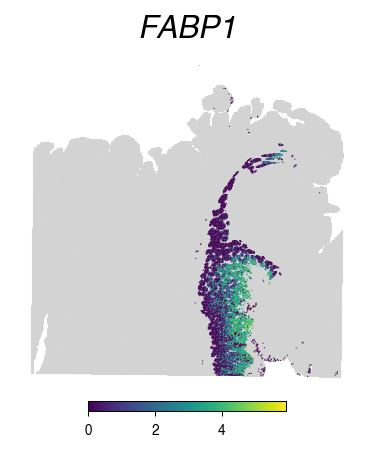

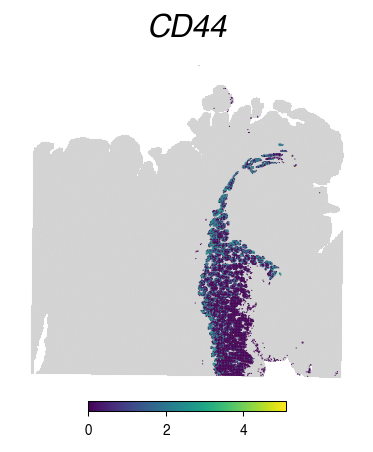

In [20]:

gene_list = ['OLFM4', 'FABP1', "CD44"]

mask = sdata_crop1['square_016um'].obsm['proportion']['Goblet'] > 0.1
for gene in gene_list:
    data = sdata_crop1['square_016um'][:, gene].X.toarray()
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    background = ax.scatter(
        sdata_crop1['square_016um'].obsm['spatial'][:, 0],
        -sdata_crop1['square_016um'].obsm['spatial'][:, 1],
        c='lightgray',
        s=0.3,
        linewidths=0
    )
    sc = ax.scatter(
        sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
        -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
        c=data[mask],
        s=0.3,
        cmap='viridis',
        linewidths=0
    )

    cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')

    #cb.set_label('Expression', fontsize=12)

    #cb.set_ticks([])
    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(gene, fontsize=15, fontstyle='italic')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [7]:
adata    = sdata_crop1['square_016um']
adata.obs['cell_type'] = adata.obsm['proportion'].idxmax(axis=1)

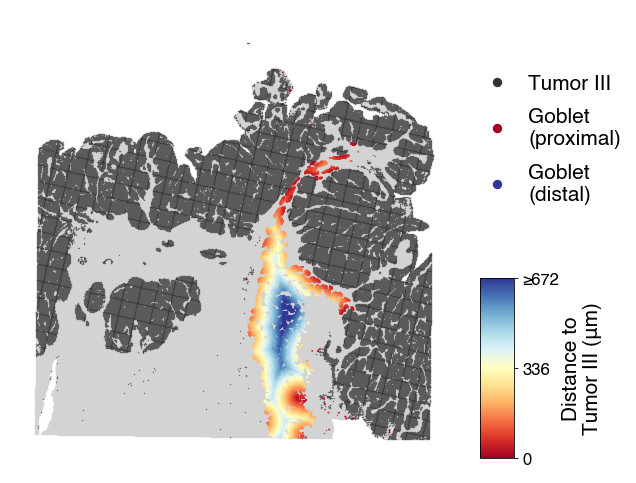

In [ ]:

# ============================================================
# 图1：空间地图 — Goblet spots 按距 Tumor III 距离染色
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739   # 16μm / 58.41 px

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]
xy          = adata.obsm['spatial']

tree = cKDTree(tumor_xy)
min_dist, _ = tree.query(goblet_xy, k=1)
dist_um  = min_dist * PIXEL_UM
dist_cap = np.percentile(dist_um, 98)
cmap_g   = plt.cm.RdYlBu
norm_g   = Normalize(vmin=0, vmax=dist_cap)

fig = plt.figure(figsize=(3.8, 3.4))
gs  = GridSpec(2, 2,
               width_ratios=[1, 0.22],
               height_ratios=[0.55, 0.45],
               wspace=0.05, hspace=0.0,
               left=0.01, right=0.97, top=0.95, bottom=0.06)

ax_main = fig.add_subplot(gs[:, 0])
ax_leg  = fig.add_subplot(gs[0, 1])
ax_cb   = fig.add_subplot(gs[1, 1])

ax_main.scatter(xy[:, 0], -xy[:, 1],
                c='lightgray', s=0.5, linewidths=0,
                rasterized=True, zorder=1)
ax_main.scatter(xy[tumor_mask, 0], -xy[tumor_mask, 1],
                c='#333333', s=0.5, linewidths=0, alpha=0.6,
                rasterized=True, zorder=2)
ax_main.scatter(goblet_xy[:, 0], -goblet_xy[:, 1],
                c=dist_um, cmap=cmap_g, norm=norm_g,
                s=1.0, linewidths=0, rasterized=True, zorder=3)

ax_main.set_aspect('equal', adjustable='box')
ax_main.set_xticks([]); ax_main.set_yticks([])
for sp in ax_main.spines.values():
    sp.set_visible(False)

# ── legend ──
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='#333333', markersize=4.5,
           label='Tumor III', markeredgewidth=0),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cmap_g(norm_g(0)), markersize=4.5,
           label='Goblet\n(proximal)', markeredgewidth=0),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cmap_g(norm_g(dist_cap)), markersize=4.5,
           label='Goblet\n(distal)', markeredgewidth=0),
]
ax_leg.legend(handles=legend_elements,
              loc='center left', fontsize=10,
              frameon=False, handletextpad=0.5,
              labelspacing=0.7, borderpad=0)
ax_leg.axis('off')

# ── colorbar──
ax_cb.axis('off')
cax = ax_cb.inset_axes([0.15, 0.05, 0.35, 0.88])
cb = ColorbarBase(cax, cmap=cmap_g, norm=norm_g, orientation='vertical')
cb.set_label('Distance to\nTumor III (μm)', fontsize=10, labelpad=1.5,
             linespacing=1.1)
ticks = [0, dist_cap * 0.5, dist_cap]
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t:.0f}' for t in ticks[:-1]] + [f'≥{dist_cap:.0f}'])
cb.ax.tick_params(labelsize=8, length=2, width=0.4, pad=2)
cb.outline.set_linewidth(0.4)
plt.tight_layout()
plt.savefig('goblet_spatial_distance.jpg', dpi=600,
            bbox_inches='tight', 
            transparent=True)
plt.savefig('goblet_spatial_distance.pdf', dpi=600,
            bbox_inches='tight',
            transparent=True)
plt.show()


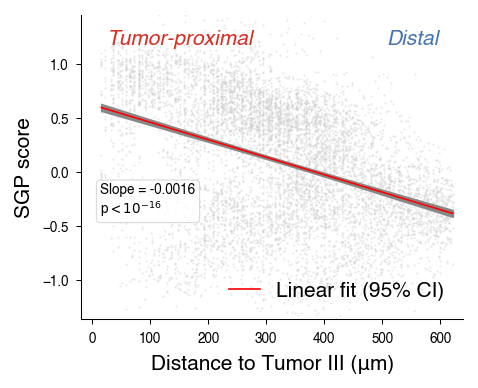

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739   # 16μm / 58.41 px

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]

tree = cKDTree(tumor_xy)
min_dist_px, _ = tree.query(goblet_xy, k=1)
dist_um = min_dist_px * PIXEL_UM

program_score = -adata.obsm['factor'][ct].values[goblet_mask]

dist_cap = np.percentile(dist_um, 95)
mask_use = dist_um <= dist_cap
x = dist_um[mask_use]
y = program_score[mask_use]
            
from scipy.stats import linregress, t as t_dist
slope, intercept, r_value, p_lm, se_slope = linregress(x, y)
x_fit  = np.linspace(x.min(), x.max(), 300)
y_fit  = slope * x_fit + intercept
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_val = 1 - ss_res / ss_tot
n      = len(x)
Sxx    = np.sum((x - x.mean()) ** 2)
s_err  = np.sqrt(ss_res / (n - 2))
se_int = s_err * np.sqrt(np.sum(x**2) / (n * Sxx))
t_crit = t_dist.ppf(0.975, df=n - 2)
slope_ci = (slope - t_crit * se_slope, slope + t_crit * se_slope)
int_ci   = (intercept - t_crit * se_int,  intercept + t_crit * se_int)


fig, ax = plt.subplots(figsize=(3.2, 2.6))

rng     = np.random.default_rng(42)
subsamp = rng.choice(len(x), size=len(x), replace=False)
ax.scatter(x[subsamp], y[subsamp],
           c='#D0D0D0', s=1.0, linewidths=0, alpha=0.5,
           rasterized=True, zorder=1)

se_mean  = s_err * np.sqrt(1.0/n + (x_fit - x.mean())**2 / Sxx)
y_lo_ci  = y_fit - t_crit * se_mean
y_hi_ci  = y_fit + t_crit * se_mean

ax.fill_between(x_fit, y_lo_ci, y_hi_ci,
                color='#888888', alpha=1, linewidth=1, zorder=2)
ax.plot(x_fit, y_fit,
        color='Red', lw=0.8, zorder=3, label='Linear fit (95% CI)')

ax.set_xlabel('Distance to Tumor III (μm)', fontsize=10)
ax.set_ylabel('SGP score', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=6.5)
ax.set_xlim(-dist_cap * 0.03, dist_cap * 1.03)
y_lo  = np.percentile(y, 2)
y_hi  = np.percentile(y, 98)                                                                                                                                                                                                                                                                                            
y_pad = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)  

p_str = f"p = {p_lm:.2e}" if p_lm >= 1e-16 else "p < $10^{-16}$"
annot = f"Slope = {slope:.4f}\n{p_str}"
ax.text(0.05, 0.450, annot,
        transform=ax.transAxes, fontsize=6.5,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#CCCCCC", linewidth=0.5, alpha=0.8))
slope_per100 = slope * 100
ci_lo_100, ci_hi_100 = slope_ci[0]*100, slope_ci[1]*100

ymin, ymax = ax.get_ylim()
dy = ymax - ymin
ax.text(dist_cap * 0.04, ymax - dy * 0.05,
        'Tumor-proximal', fontsize=10, color='#D73027',
        ha='left', va='top', fontstyle='italic')
ax.text(dist_cap * 0.96, ymax - dy * 0.05,
        'Distal', fontsize=10, color='#4575B4',
        ha='right', va='top', fontstyle='italic')

legend_elements = [
    Line2D([0], [0], color='Red', lw=0.8, label='Linear fit (95% CI)'),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False,
          loc='lower right', handlelength=1.5)

plt.tight_layout()
plt.savefig('goblet_distance_lineplot.pdf', dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

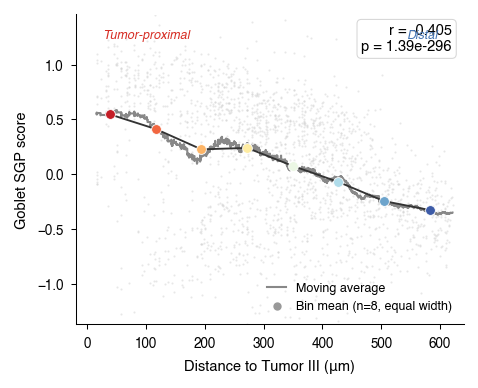

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from scipy.ndimage import uniform_filter1d
from scipy.stats import spearmanr

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]

tree = cKDTree(tumor_xy)
min_dist_px, _ = tree.query(goblet_xy, k=1)
dist_um = min_dist_px * PIXEL_UM

program_score = -adata.obsm['factor'][ct].values[goblet_mask]

dist_cap = np.percentile(dist_um, 95)
mask_use = dist_um <= dist_cap
x = dist_um[mask_use]
y = program_score[mask_use]

sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]
window   = max(len(x_sorted) // 30, 10)
y_smooth = uniform_filter1d(y_sorted.astype(float), size=window)

N_BINS    = 8
bin_edges = np.linspace(0, dist_cap, N_BINS + 1)
bin_mids  = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    vals = y[(x >= lo) & (x < hi)]
    bin_means.append(vals.mean() if len(vals) >= 5 else np.nan)
bin_means = np.array(bin_means)
valid     = ~np.isnan(bin_means)

cmap_line  = plt.cm.RdYlBu
norm_line  = mpl.colors.Normalize(vmin=0, vmax=dist_cap)
bin_colors = [cmap_line(norm_line(m)) for m in bin_mids]

fig, ax = plt.subplots(figsize=(3.2, 2.6))

rng     = np.random.default_rng(42)
subsamp = rng.choice(len(x), size=min(2000, len(x)), replace=False)
ax.scatter(x[subsamp], y[subsamp],
           c='#D0D0D0', s=1.0, linewidths=0, alpha=0.5,
           rasterized=True, zorder=1)

ax.plot(x_sorted, y_smooth,
        color='#888888', lw=1.0, zorder=2, label='Moving average')

ax.plot(bin_mids[valid], bin_means[valid],
        color='#333333', lw=0.9, zorder=2)

for mid, mean, col in zip(bin_mids[valid], bin_means[valid],
                           [bin_colors[i] for i, v in enumerate(valid) if v]):
    ax.scatter(mid, mean, color=col, s=22,
               edgecolors='white', linewidths=0.4, zorder=3)

ax.set_xlabel('Distance to Tumor III (μm)', fontsize=7)
ax.set_ylabel('Goblet SGP score', fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=6.5)
ax.set_xlim(-dist_cap * 0.03, dist_cap * 1.03)
y_lo  = np.percentile(y, 2)
y_hi  = np.percentile(y, 98)
y_pad = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

r_val, p_val = spearmanr(x, y)
ax.text(0.97, 0.97,
        f"r = {r_val:.3f}\np = {p_val:.2e}",
        transform=ax.transAxes, fontsize=7,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CCCCCC', linewidth=0.5, alpha=0.8))

ymin, ymax = ax.get_ylim()
dy = ymax - ymin
ax.text(dist_cap * 0.04, ymax - dy * 0.05,
        'Tumor-proximal', fontsize=6, color='#D73027',
        ha='left', va='top', fontstyle='italic')
ax.text(dist_cap * 0.96, ymax - dy * 0.05,
        'Distal', fontsize=6, color='#4575B4',
        ha='right', va='top', fontstyle='italic')

legend_elements = [
    Line2D([0], [0], color='#888888', lw=1.0, label='Moving average'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#999999', markersize=4,
           label=f'Bin mean (n={N_BINS}, equal width)', markeredgewidth=0),
]
ax.legend(handles=legend_elements, fontsize=6, frameon=False,
          loc='lower right', handlelength=1.5)

plt.tight_layout()
plt.savefig('goblet_distance_lineplot_orig.pdf', dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()
